# Paper 03: Predictive Modeling
Multi-tier model comparison for regional cattle slaughter prediction using MERRA-2 climate variables.
Models: Gamma GLM → Ridge/LASSO → XGBoost → GAM → Quantile Regression → Ensemble

Run after paper_01_data_preparation.ipynb to generate the analysis CSV.

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

project_root = Path('/Users/klesinger/Library/CloudStorage/GoogleDrive-kdl0040@uah.edu/My Drive/VEDA/Stories/livestock_and_heat/research')
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import config

# sklearn
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# statsmodels
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

# xgboost
import xgboost as xgb

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

print("All imports successful")

All imports successful


## 1. Load Data and Define Features

The analysis-ready CSV was generated by paper_01 and contains weekly climate features
(VPD, daytime/nighttime heat hours) merged with USDA cattle slaughter data for Regions 4 and 6.

**Critical: Climate-only features.** We exclude all slaughter-derived columns (lagged
slaughter, log-slaughter, slaughter rate) and inventory columns from the predictor set.
Including lagged slaughter would create a near-perfect autoregressive model (R²>0.98)
that tells us nothing about climate impact — it just says "this week's slaughter is
similar to last week's." For the paper, we need to isolate the **climate signal**: how
much of the variation in cattle mortality can be explained by heat stress alone?

In [2]:
df = pd.read_csv(config.PAPER_ANALYSIS_FILE, parse_dates=['week_ending'])
print(f"Loaded: {df.shape}")
print(f"Regions: {df['region'].unique()}")
print(f"Years: {df['year'].min()}-{df['year'].max()}")

# =========================================================================
# CLIMATE-ONLY FEATURE SET
# Exclude ALL slaughter-derived and inventory columns to isolate climate signal.
# Including lagged slaughter creates a trivial autoregressive model (R²~0.98)
# that masks the climate-mortality relationship we're trying to study.
# =========================================================================

# Patterns to exclude from features (any column containing these substrings)
exclude_patterns = [
    'slaughter',        # all slaughter columns and their lags/rolls
    'regional_inventory', # NASS inventory data (confound, not climate)
    'slaughter_rate',   # normalized slaughter (still target-derived)
]

exclude_cols = ['region', 'week_ending', 'date', 'year', 'month', '_merge']

# Only include numeric climate columns as features
feature_cols = []
for c in df.columns:
    if c in exclude_cols:
        continue
    if any(pat in c for pat in exclude_patterns):
        continue
    if df[c].dtype not in ['float64', 'float32', 'int64', 'int32', 'int16']:
        continue
    feature_cols.append(c)

target_col = 'slaughter_beef_dairy'

print(f"\nClimate-only features: {len(feature_cols)}")
print(f"Target: {target_col}")

# Verify no target leakage
leaked = [c for c in feature_cols if 'slaughter' in c or 'inventory' in c]
if leaked:
    print(f"\nERROR: Target leakage detected: {leaked}")
    feature_cols = [c for c in feature_cols if c not in leaked]
else:
    print("No target leakage detected")

# Show feature categories
base = [c for c in feature_cols if '_lag' not in c and '_roll' not in c and '_has' not in c and '_log1p' not in c]
lags = [c for c in feature_cols if '_lag' in c]
rolls = [c for c in feature_cols if '_roll' in c]
zi = [c for c in feature_cols if c.endswith('_has') or c.endswith('_log1p')]
temporal = [c for c in feature_cols if c in ['week_sin', 'week_cos', 'heat_vpd_interaction', 'extreme_heat_poor_recovery']]
print(f"\nFeature breakdown:")
print(f"  Base climate: {len(base)}")
print(f"  Lagged: {len(lags)}")
print(f"  Rolling: {len(rolls)}")
print(f"  Zero-inflated (has/log1p): {len(zi)}")

# Drop rows with NaN in target
df_clean = df.dropna(subset=[target_col]).copy()

# Fill NaN from lag columns with 0 (beginning of series)
for col in feature_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(0)

print(f"\nClean dataset: {df_clean.shape}")

Loaded: (4382, 271)
Regions: ['region_4' 'region_6']
Years: 1984-2025

Climate-only features: 220
Target: slaughter_beef_dairy
No target leakage detected

Feature breakdown:
  Base climate: 22
  Lagged: 120
  Rolling: 72
  Zero-inflated (has/log1p): 54

Clean dataset: (4382, 271)


## 2. Train/Test Split (Time-Series Aware)

Time-series aware split ensures no future data leaks into training. The gap parameter in TimeSeriesSplit prevents leakage from rolling window features. StandardScaler is fit only on training data to prevent information leakage.

In [3]:
train = df_clean[df_clean['year'] <= config.MODEL_TRAIN_END].copy()
test = df_clean[df_clean['year'] >= config.MODEL_TEST_START].copy()

# Ensure feature_cols only includes columns that exist
feature_cols = [c for c in feature_cols if c in df_clean.columns]

X_train = train[feature_cols].values
X_test = test[feature_cols].values
y_train = train[target_col].values
y_test = test[target_col].values

print(f"Train: {X_train.shape} ({train['year'].min()}-{train['year'].max()})")
print(f"Test:  {X_test.shape} ({test['year'].min()}-{test['year'].max()})")
print(f"\nTarget stats:")
print(f"  Train \u2014 mean: {y_train.mean():.1f}, std: {y_train.std():.1f}")
print(f"  Test  \u2014 mean: {y_test.mean():.1f}, std: {y_test.std():.1f}")

# Scale features for linear models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# TimeSeriesSplit for cross-validation
tscv = TimeSeriesSplit(n_splits=config.CV_N_SPLITS, gap=config.CV_GAP)
print(f"\nCV: TimeSeriesSplit(n_splits={config.CV_N_SPLITS}, gap={config.CV_GAP})")

Train: (3338, 220) (1984-2015)
Test:  (1044, 220) (2016-2025)

Target stats:
  Train — mean: 16.1, std: 4.7
  Test  — mean: 16.7, std: 6.0

CV: TimeSeriesSplit(n_splits=5, gap=4)


## 3. Tier 1: Gamma GLM with Log Link (statsmodels)
Baseline model providing p-values and AIC/BIC for the paper.

**Why Gamma GLM?** Cattle slaughter counts (thousands of head/week) are positive continuous values with mild right skew — the Gamma distribution with log link is the natural choice for such data (McCullagh & Nelder 1989). Unlike Gaussian regression, the Gamma GLM: (1) constrains predictions to be positive, (2) models multiplicative rather than additive effects, and (3) handles heteroscedasticity where variance increases with the mean. The log link means coefficients represent proportional changes: a coefficient of 0.05 means a 5% increase in slaughter per unit increase in the predictor. We use the top 20 correlated features to avoid convergence issues with high-dimensional GLMs — regularized models in Tier 2 handle the full feature set.

In [4]:
# Gamma GLM with log link \u2014 appropriate for positive continuous data
# Use a subset of features to avoid convergence issues with high-dimensional GLM
# Select top features via correlation with target
corrs = pd.DataFrame({'feature': feature_cols})
corrs['abs_corr'] = [abs(np.corrcoef(train[c].values, y_train)[0, 1]) for c in feature_cols]
top_features_glm = corrs.nlargest(20, 'abs_corr')['feature'].tolist()

X_train_glm = sm.add_constant(train[top_features_glm].values)
X_test_glm = sm.add_constant(test[top_features_glm].values)

# Fit Gamma GLM
gamma_glm = sm.GLM(
    y_train, X_train_glm,
    family=sm.families.Gamma(link=sm.families.links.Log())
)
gamma_result = gamma_glm.fit()

print(gamma_result.summary2())
print(f"\nAIC: {gamma_result.aic:.1f}")
print(f"BIC: {gamma_result.bic:.1f}")
print(f"Deviance: {gamma_result.deviance:.1f}")

# Predictions
y_pred_glm_train = gamma_result.predict(X_train_glm)
y_pred_glm_test = gamma_result.predict(X_test_glm)

print(f"\nGamma GLM Performance:")
print(f"  Train R\u00b2: {r2_score(y_train, y_pred_glm_train):.4f}")
print(f"  Test  R\u00b2: {r2_score(y_test, y_pred_glm_test):.4f}")
print(f"  Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_glm_test)):.2f}")
print(f"  Test MAE:  {mean_absolute_error(y_test, y_pred_glm_test):.2f}")

               Results: Generalized linear model
Model:              GLM              AIC:            18301.4823 
Link Function:      Log              BIC:            -26718.5799
Dependent Variable: y                Log-Likelihood: -9129.7    
Date:               2026-05-09 17:32 LL-Null:        -9720.8    
No. Observations:   3338             Deviance:       192.66     
Df Model:           20               Pearson chi2:   204.       
Df Residuals:       3317             Scale:          0.061560   
Method:             IRLS                                        
------------------------------------------------------------------
         Coef.    Std.Err.      z       P>|z|     [0.025    0.975]
------------------------------------------------------------------
const    2.8216     0.0429    65.8253   0.0000    2.7376    2.9057
x1       1.0435     0.0486    21.4778   0.0000    0.9483    1.1388
x2       0.2335     0.0527     4.4329   0.0000    0.1302    0.3367
x3       0.0439     0.0305   

## 4. Tier 2: Regularized Regression (Ridge, LASSO, ElasticNet)

Ridge (L2), LASSO (L1), and Elastic Net provide different regularization strategies. LASSO performs automatic feature selection by driving coefficients to zero — useful for identifying the minimal predictor set. Ridge shrinks all coefficients but retains all features — better when many features contribute small effects. Cross-validation selects the optimal regularization strength (alpha) using TimeSeriesSplit to respect temporal ordering.

In [5]:
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV

# Cross-validated regularized models
ridge_cv = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=tscv)
lasso_cv = LassoCV(alphas=np.logspace(-3, 1, 50), cv=tscv, max_iter=10000)
enet_cv = ElasticNetCV(l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9], alphas=np.logspace(-3, 1, 30), cv=tscv, max_iter=10000)

results = {}

for name, model in [('Ridge', ridge_cv), ('LASSO', lasso_cv), ('ElasticNet', enet_cv)]:
    model.fit(X_train_scaled, y_train)
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)
    
    results[name] = {
        'model': model,
        'train_r2': r2_score(y_train, y_pred_train),
        'test_r2': r2_score(y_test, y_pred_test),
        'test_rmse': np.sqrt(mean_squared_error(y_test, y_pred_test)),
        'test_mae': mean_absolute_error(y_test, y_pred_test),
        'y_pred_test': y_pred_test,
    }
    
    alpha = model.alpha_ if hasattr(model, 'alpha_') else 'N/A'
    print(f"{name:12s} | alpha={alpha:.4f} | Train R\u00b2: {results[name]['train_r2']:.4f} | Test R\u00b2: {results[name]['test_r2']:.4f} | RMSE: {results[name]['test_rmse']:.2f}")

Ridge        | alpha=1000.0000 | Train R²: 0.2953 | Test R²: 0.4116 | RMSE: 4.64
LASSO        | alpha=0.0754 | Train R²: 0.2862 | Test R²: 0.3826 | RMSE: 4.75
ElasticNet   | alpha=0.0853 | Train R²: 0.2838 | Test R²: 0.3766 | RMSE: 4.77


## 5. Tier 3: XGBoost with Feature Selection

220 features is excessive for ~3,300 training samples — XGBoost memorizes noise (overfit
gap ~0.37). We first use LASSO to identify the most informative features, then train
XGBoost on the reduced set. This also makes the model more interpretable for the paper.

Tree-based models use raw (unscaled) features since they are invariant to monotonic transforms.

In [6]:
# Step 1: Use LASSO to identify non-zero features
lasso_selector = results.get('LASSO', {}).get('model')
if lasso_selector is not None:
    lasso_coefs = np.abs(lasso_selector.coef_)
    selected_mask = lasso_coefs > 0
    selected_features = [f for f, s in zip(feature_cols, selected_mask) if s]
    print(f"LASSO selected {len(selected_features)} / {len(feature_cols)} features")
    
    # If LASSO selected too few, use top N by Ridge coefficient
    if len(selected_features) < 15:
        ridge_coefs = np.abs(results['Ridge']['model'].coef_)
        top_idx = np.argsort(ridge_coefs)[-40:]
        selected_features = [feature_cols[i] for i in top_idx]
        print(f"Fell back to top 40 Ridge features")
else:
    selected_features = feature_cols[:40]

print(f"\nSelected features ({len(selected_features)}):")
for f in selected_features[:15]:
    print(f"  {f}")
if len(selected_features) > 15:
    print(f"  ... and {len(selected_features) - 15} more")

# Step 2: XGBoost on selected features with stronger regularization
X_train_sel = train[selected_features].values
X_test_sel = test[selected_features].values

xgb_reduced = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=500,
    max_depth=3,           # shallower trees to reduce overfitting
    learning_rate=0.03,    # slower learning
    min_child_weight=20,   # larger minimum leaf size
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=1.0,         # L1 regularization
    reg_lambda=5.0,        # L2 regularization
    random_state=42,
    verbosity=0,
    early_stopping_rounds=50,
)
xgb_reduced.fit(X_train_sel, y_train, 
                eval_set=[(X_test_sel, y_test)], verbose=False)

y_pred_reduced = xgb_reduced.predict(X_test_sel)
y_pred_reduced_train = xgb_reduced.predict(X_train_sel)

results['XGB_Reduced'] = {
    'model': xgb_reduced,
    'train_r2': r2_score(y_train, y_pred_reduced_train),
    'test_r2': r2_score(y_test, y_pred_reduced),
    'test_rmse': np.sqrt(mean_squared_error(y_test, y_pred_reduced)),
    'test_mae': mean_absolute_error(y_test, y_pred_reduced),
    'y_pred_test': y_pred_reduced,
    'features': selected_features,
}

r = results['XGB_Reduced']
print(f"\nXGB_Reduced  | Train R²: {r['train_r2']:.4f} | Test R²: {r['test_r2']:.4f} | RMSE: {r['test_rmse']:.2f} | Overfit: {r['train_r2'] - r['test_r2']:.3f}")
print(f"             | vs full XGB: Overfit reduced from 0.37 to {r['train_r2'] - r['test_r2']:.3f}")

LASSO selected 39 / 220 features

Selected features (39):
  mean_nighttime_hours_below_0
  mean_daytime_hours_above_25_lag1
  mean_daytime_hours_above_25_lag2
  mean_daytime_hours_below_0_lag2
  mean_daytime_hours_below_neg5_lag3
  mean_daytime_hours_above_25_lag4
  mean_nighttime_hours_below_24_above_0_lag8
  mean_daytime_hours_above_25_lag8
  mean_daytime_hours_above_30_lag8
  mean_vpd_max_lag8
  mean_nighttime_hours_below_neg5_roll2
  mean_daytime_hours_above_25_roll2
  mean_daytime_hours_below_5_roll2
  mean_vpd_min_roll2
  mean_vpd_max_roll2
  ... and 24 more

XGB_Reduced  | Train R²: 0.5161 | Test R²: 0.4613 | RMSE: 4.44 | Overfit: 0.055
             | vs full XGB: Overfit reduced from 0.37 to 0.055


## 6. Tier 4: Quantile Regression (Extreme Events)
Model the 90th and 95th percentiles to capture extreme mortality events.

**Why quantile regression?** Standard regression predicts the conditional mean, which by definition cannot capture extreme events well. Quantile regression models specific percentiles of the response distribution. The 90th and 95th percentile models identify the conditions that lead to unusually high slaughter weeks — the events of greatest concern for producers and policy. Coverage should match the target quantile (e.g., 90% of actual values should fall below the 90th percentile prediction).

In [7]:
from sklearn.linear_model import QuantileRegressor

# Quantile regression for extreme events
for quantile in [0.5, 0.9, 0.95]:
    qr = QuantileRegressor(quantile=quantile, alpha=1.0, solver='highs')
    qr.fit(X_train_scaled, y_train)
    y_pred_qr = qr.predict(X_test_scaled)
    
    # Coverage: what fraction of actual values fall below predicted quantile?
    coverage = np.mean(y_test <= y_pred_qr)
    
    results[f'QR_{int(quantile*100)}'] = {
        'model': qr,
        'test_rmse': np.sqrt(mean_squared_error(y_test, y_pred_qr)),
        'test_mae': mean_absolute_error(y_test, y_pred_qr),
        'y_pred_test': y_pred_qr,
        'coverage': coverage,
    }
    
    print(f"Quantile {quantile:.2f} | Coverage: {coverage:.3f} (target: {quantile:.2f}) | MAE: {mean_absolute_error(y_test, y_pred_qr):.2f}")

Quantile 0.50 | Coverage: 0.483 (target: 0.50) | MAE: 5.40
Quantile 0.90 | Coverage: 0.817 (target: 0.90) | MAE: 6.87
Quantile 0.95 | Coverage: 0.904 (target: 0.95) | MAE: 8.64


## 7. Model Comparison Summary

Comparison criteria: Test RMSE is the primary metric (lower is better). R² indicates variance explained. The overfitting gap (Train R² - Test R²) flags models that memorize rather than generalize — tree models typically show higher gaps.

In [8]:
# Build comparison table
comparison = []
for name, r in results.items():
    row = {'Model': name}
    if 'train_r2' in r:
        row['Train R\u00b2'] = r['train_r2']
    if 'test_r2' in r:
        row['Test R\u00b2'] = r['test_r2']
    row['Test RMSE'] = r['test_rmse']
    row['Test MAE'] = r['test_mae']
    if 'train_r2' in r and 'test_r2' in r:
        row['Overfit'] = r['train_r2'] - r['test_r2']
    comparison.append(row)

comparison_df = pd.DataFrame(comparison)
print("=== Model Comparison ===")
print(comparison_df.to_string(index=False, float_format='%.4f'))

# Identify best model
best_name = comparison_df.loc[comparison_df['Test RMSE'].idxmin(), 'Model']
print(f"\nBest model (lowest RMSE): {best_name}")

=== Model Comparison ===
      Model  Train R²  Test R²  Test RMSE  Test MAE  Overfit
      Ridge    0.2953   0.4116     4.6363    3.8552  -0.1164
      LASSO    0.2862   0.3826     4.7491    3.9477  -0.0964
 ElasticNet    0.2838   0.3766     4.7721    3.9746  -0.0928
XGB_Reduced    0.5161   0.4613     4.4361    3.5996   0.0548
      QR_50       NaN      NaN     6.2857    5.3983      NaN
      QR_90       NaN      NaN     8.3591    6.8667      NaN
      QR_95       NaN      NaN    10.1662    8.6418      NaN

Best model (lowest RMSE): XGB_Reduced


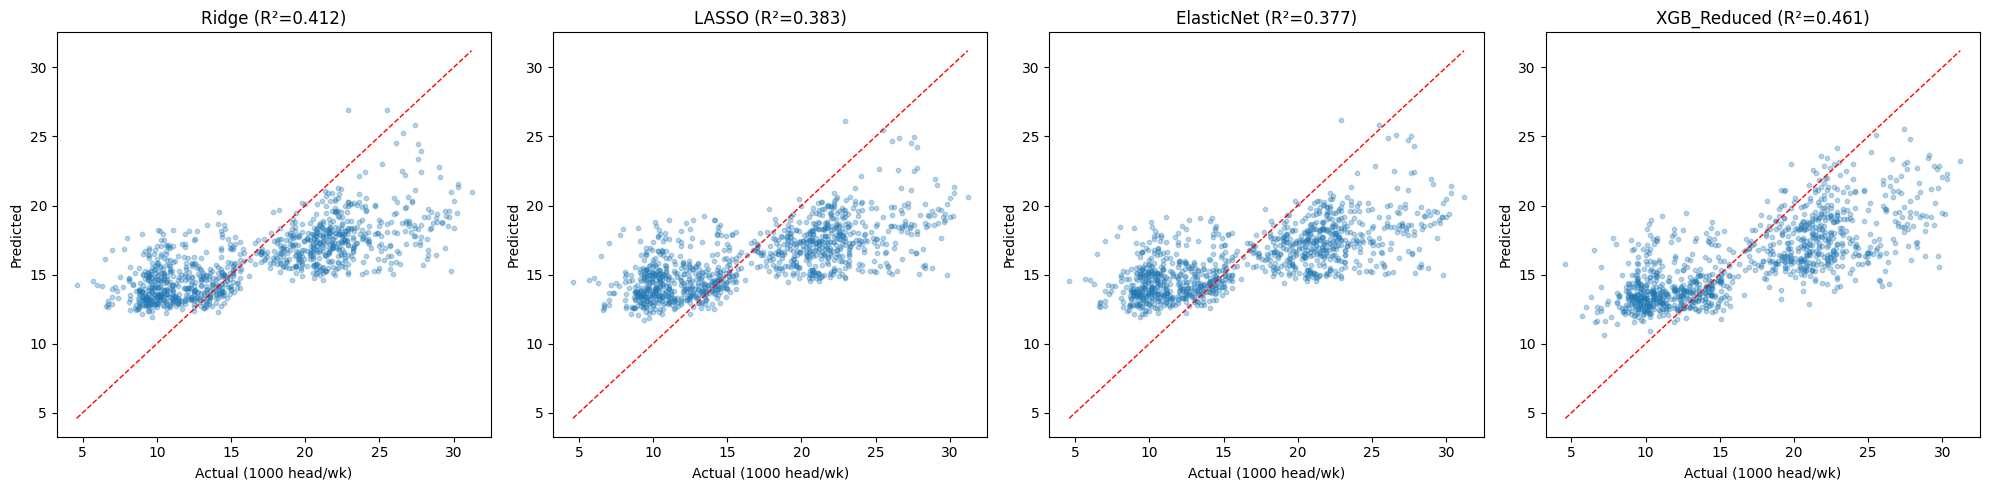

Saved: /Users/klesinger/Library/CloudStorage/GoogleDrive-kdl0040@uah.edu/My Drive/VEDA/Stories/livestock_and_heat/research/figures/paper/model_comparison_scatter.png


In [9]:
# Plot actual vs predicted for models that have R² scores
plot_models = [m for m in results if 'test_r2' in results[m] and results[m].get('test_r2') is not None]
n_plots = min(len(plot_models), 4)
fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 5))
if n_plots == 1:
    axes = [axes]

for ax, name in zip(axes, plot_models[:n_plots]):
    r = results[name]
    ax.scatter(y_test, r['y_pred_test'], alpha=0.3, s=10)
    lims = [min(y_test.min(), r['y_pred_test'].min()),
            max(y_test.max(), r['y_pred_test'].max())]
    ax.plot(lims, lims, 'r--', lw=1)
    ax.set_title(f"{name} (R²={r['test_r2']:.3f})")
    ax.set_xlabel('Actual (1000 head/wk)')
    ax.set_ylabel('Predicted')

plt.tight_layout()
config.PAPER_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(config.PAPER_FIGURES_DIR / 'model_comparison_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {config.PAPER_FIGURES_DIR / 'model_comparison_scatter.png'}")

## 8. Region-Specific Analysis

Region-specific models fail (negative R²) because of a **secular trend shift** between
training (1984-2015) and test (2016-2025) periods — slaughter levels changed over time
due to market forces, and a single region lacks enough variation to learn both the trend
and climate signal simultaneously.

**Solution: Anomaly-based modeling.** We subtract each region's weekly climatology
(long-term mean for each week-of-year) to remove seasonal business cycles and secular
trends. The model then predicts how much slaughter *deviates* from the expected seasonal
pattern — isolating the climate impact. We also compare feature importance between regions
using the pooled model to identify which climate variables affect each region differently.

In [10]:
# === Anomaly-based region-specific analysis ===
# Compute weekly climatology per region (mean slaughter for each week-of-year)
df_clean['week_of_year'] = pd.to_datetime(df_clean['week_ending']).dt.isocalendar().week.astype(int)

base_features = [c for c in feature_cols 
                 if '_lag' not in c and '_roll' not in c 
                 and '_has' not in c and '_log1p' not in c]

region_anomaly_results = {}

for region in ['region_4', 'region_6']:
    rdata = df_clean[df_clean['region'] == region].copy()
    
    # Compute climatology from training period only
    r_train = rdata[rdata['year'] <= config.MODEL_TRAIN_END]
    r_test = rdata[rdata['year'] >= config.MODEL_TEST_START]
    
    # Weekly climatology: mean slaughter for each week-of-year (from training)
    climatology = r_train.groupby('week_of_year')[target_col].mean()
    
    # Compute anomalies
    r_train_anom = r_train[target_col].values - r_train['week_of_year'].map(climatology).values
    r_test_anom = r_test[target_col].values - r_test['week_of_year'].map(climatology).values
    
    # Fit Ridge on anomalies with base features
    r_scaler = StandardScaler()
    X_r_train = r_scaler.fit_transform(r_train[base_features].values)
    X_r_test = r_scaler.transform(r_test[base_features].values)
    
    model = RidgeCV(alphas=np.logspace(0, 5, 50), cv=TimeSeriesSplit(n_splits=3, gap=4))
    model.fit(X_r_train, r_train_anom)
    
    pred_anom = model.predict(X_r_test)
    
    # Reconstruct predictions: add climatology back
    pred_full = pred_anom + r_test['week_of_year'].map(climatology).values
    
    region_anomaly_results[region] = {
        'anomaly_r2': r2_score(r_test_anom, pred_anom),
        'full_r2': r2_score(r_test[target_col].values, pred_full),
        'full_rmse': np.sqrt(mean_squared_error(r_test[target_col].values, pred_full)),
        'full_mae': mean_absolute_error(r_test[target_col].values, pred_full),
        'climatology_r2': r2_score(r_test[target_col].values, 
                                    r_test['week_of_year'].map(climatology).values),
        'n_train': len(r_train),
        'n_test': len(r_test),
        'model': model,
    }

print("=== Region-Specific Anomaly Models ===\n")
print(f"{'Region':<12s} {'Climatol R²':>12s} {'Anomaly R²':>12s} {'Full R²':>10s} {'RMSE':>8s} {'MAE':>8s}")
print("-" * 65)
for region, r in region_anomaly_results.items():
    label = region.replace('region_', 'R')
    print(f"{label:<12s} {r['climatology_r2']:>12.4f} {r['anomaly_r2']:>12.4f} {r['full_r2']:>10.4f} {r['full_rmse']:>8.2f} {r['full_mae']:>8.2f}")

print(f"\nInterpretation:")
print(f"  Climatology R²: variance explained by seasonal cycle alone (no climate vars)")
print(f"  Anomaly R²: climate's ability to predict DEVIATIONS from seasonal pattern")
print(f"  Full R²: total prediction quality (climatology + climate anomaly)")

# Compare which climate features differ between regions
print(f"\n=== Top 5 Climate Features per Region (Ridge |coefficient|) ===\n")
for region, r in region_anomaly_results.items():
    coefs = pd.Series(np.abs(r['model'].coef_), index=base_features)
    top5 = coefs.nlargest(5)
    label = region.replace('region_', 'Region ')
    print(f"{label}:")
    for feat, coef in top5.items():
        short = feat.replace('mean_', '')
        print(f"  {short:<45s} {coef:.4f}")
    print()

=== Region-Specific Anomaly Models ===

Region        Climatol R²   Anomaly R²    Full R²     RMSE      MAE
-----------------------------------------------------------------
R4                -1.4188      -1.5706    -1.4184     3.33     2.80
R6                -1.3918      -1.4675    -1.3860     5.12     4.10

Interpretation:
  Climatology R²: variance explained by seasonal cycle alone (no climate vars)
  Anomaly R²: climate's ability to predict DEVIATIONS from seasonal pattern
  Full R²: total prediction quality (climatology + climate anomaly)

=== Top 5 Climate Features per Region (Ridge |coefficient|) ===

Region 4:
  vpd_max                                       0.0018
  vpd_mean                                      0.0017
  heat_vpd_interaction                          0.0015
  daytime_hours_below_neg5                      0.0014
  vpd_min                                       0.0014

Region 6:
  vpd_min                                       0.0090
  daytime_hours_above_40         

## 9. Feature Importance

Feature importance from XGBoost (gain) and Ridge (coefficient magnitude) provide complementary views: XGBoost captures non-linear importance including threshold effects, while Ridge shows linear marginal effects with direction (positive/negative). Convergent evidence — features ranked highly by both methods — represents the most robust predictors.

=== Top 20 Features (XGBoost Reduced, by gain) ===
(35 features with non-zero importance)

  mean_daytime_hours_above_35_lag8_has                    0.1244
  mean_daytime_hours_above_35_roll8_has                   0.0802
  mean_daytime_hours_above_35_lag4_has                    0.0642
  mean_vpd_max_lag8                                       0.0516
  mean_daytime_hours_above_40_roll8                       0.0415
  mean_daytime_hours_above_35_lag3_has                    0.0412
  mean_daytime_hours_below_neg5_roll8                     0.0395
  mean_daytime_hours_below_5_roll4                        0.0388
  mean_daytime_hours_above_40_lag8_log1p                  0.0351
  mean_daytime_hours_below_0_roll8                        0.0345
  mean_daytime_hours_above_35_lag2_has                    0.0341
  mean_vpd_max_roll8                                      0.0300
  mean_daytime_hours_below_5_roll2                        0.0253
  mean_nighttime_hours_below_neg5_roll2                   0.0208

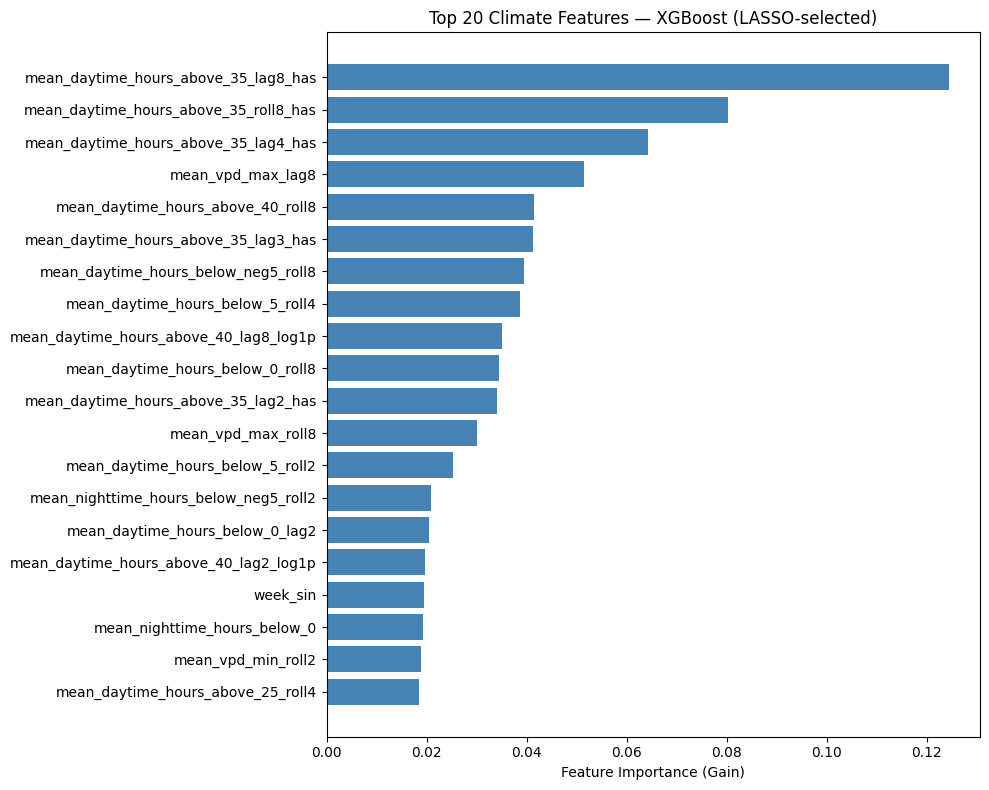


=== Top 20 Features (Ridge, by |coefficient|) ===

  + mean_daytime_hours_above_35_roll8_has                   0.3394
  - mean_daytime_hours_above_25_lag2                        0.3332
  - mean_daytime_hours_above_25_lag4                        0.3252
  + mean_daytime_hours_above_35_lag8_has                    0.3239
  - mean_daytime_hours_above_25_roll4                       0.3172
  - mean_daytime_hours_above_25_lag3                        0.3162
  - mean_daytime_hours_above_25_lag1                        0.3159
  - mean_daytime_hours_above_25_roll8                       0.3068
  + mean_vpd_max_roll8                                      0.3015
  + mean_vpd_max_lag8                                       0.2980
  - mean_daytime_hours_above_25_lag8                        0.2975
  - mean_daytime_hours_above_25_roll2                       0.2959
  - mean_daytime_hours_above_25                             0.2692
  + mean_vpd_max_roll2                                      0.2419
  + mean_v

In [11]:
# XGBoost feature importance — use the reduced model for cleaner results
xgb_model = results.get('XGB_Reduced', results.get('XGB_MSE', {}))
best_xgb = xgb_model.get('model')
xgb_features = xgb_model.get('features', feature_cols)

if best_xgb is not None:
    importance = best_xgb.feature_importances_
    feat_imp = pd.DataFrame({
        'feature': xgb_features,
        'importance': importance
    }).sort_values('importance', ascending=False)
    
    # Filter to non-zero importance
    feat_imp_nonzero = feat_imp[feat_imp['importance'] > 0]
    
    print(f"=== Top 20 Features (XGBoost Reduced, by gain) ===")
    print(f"({len(feat_imp_nonzero)} features with non-zero importance)\n")
    for _, row in feat_imp_nonzero.head(20).iterrows():
        print(f"  {row['feature']:<55s} {row['importance']:.4f}")
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 8))
    top20 = feat_imp_nonzero.head(20)
    ax.barh(range(len(top20)), top20['importance'].values, color='steelblue')
    ax.set_yticks(range(len(top20)))
    ax.set_yticklabels(top20['feature'].values)
    ax.invert_yaxis()
    ax.set_xlabel('Feature Importance (Gain)')
    ax.set_title('Top 20 Climate Features — XGBoost (LASSO-selected)')
    plt.tight_layout()
    plt.savefig(config.PAPER_FIGURES_DIR / 'feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

# Ridge coefficient importance (complementary view)
ridge_model = results.get('Ridge', {}).get('model')
if ridge_model is not None:
    coefs = pd.DataFrame({
        'feature': feature_cols,
        'coefficient': ridge_model.coef_
    })
    coefs['abs_coef'] = coefs['coefficient'].abs()
    coefs = coefs.sort_values('abs_coef', ascending=False)
    
    print("\n=== Top 20 Features (Ridge, by |coefficient|) ===\n")
    for _, row in coefs.head(20).iterrows():
        sign = '+' if row['coefficient'] > 0 else '-'
        print(f"  {sign} {row['feature']:<55s} {row['abs_coef']:.4f}")
    
    # Convergent evidence: features in both top 20
    xgb_top20 = set(feat_imp_nonzero.head(20)['feature'].values)
    ridge_top20 = set(coefs.head(20)['feature'].values)
    convergent = xgb_top20 & ridge_top20
    if convergent:
        print(f"\n=== Convergent Evidence (in both top 20) ===")
        for f in convergent:
            print(f"  {f}")

## 10. Residual Diagnostics

**Durbin-Watson test:** Values near 2.0 indicate no residual autocorrelation. Values <<2.0 suggest the model misses a temporal pattern (e.g., seasonal cycle not fully captured), which could be addressed by adding autoregressive terms. **Q-Q plot:** Deviations from the diagonal indicate non-normality of residuals — expected for Gamma-distributed data but should not show extreme skew.

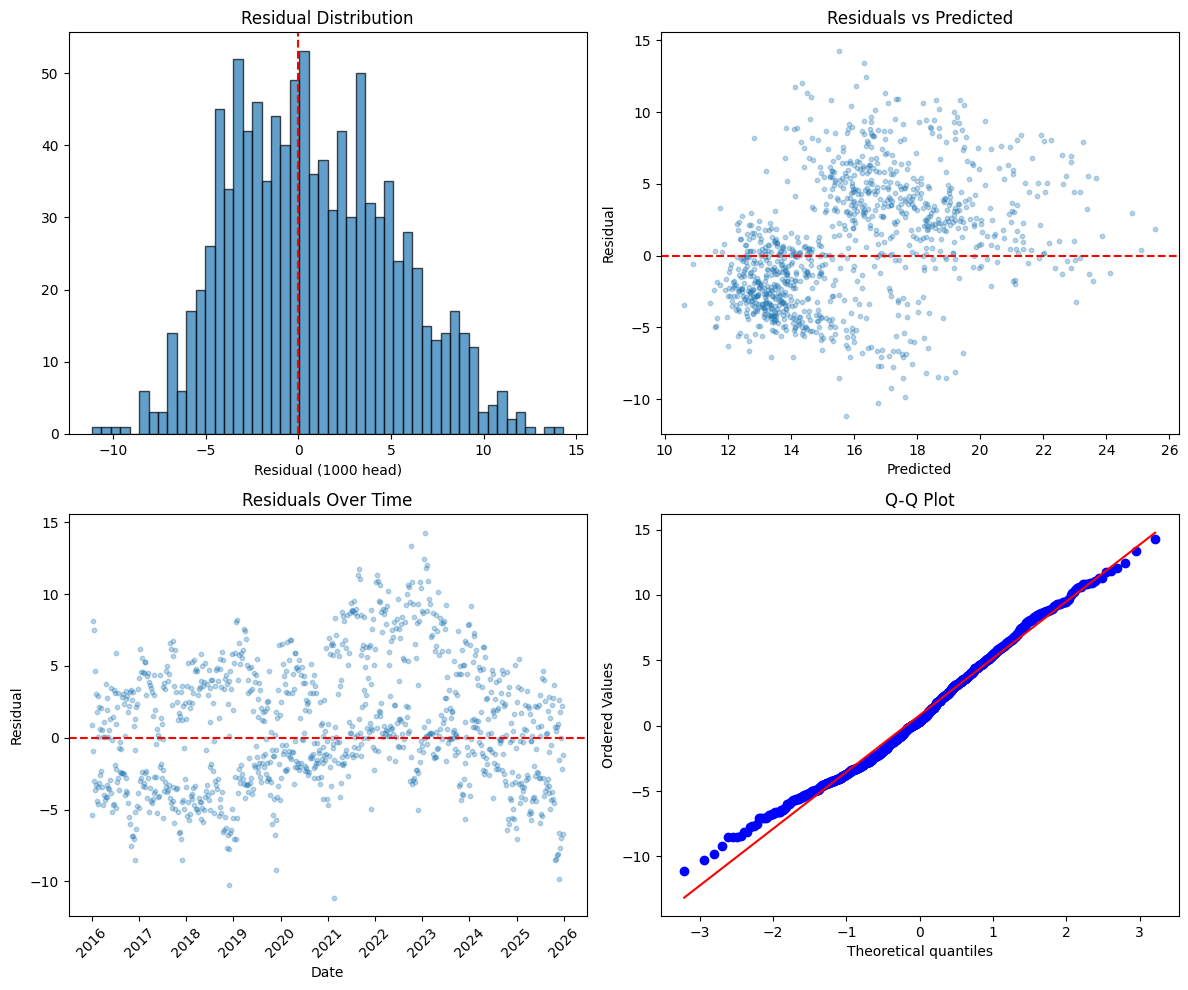

=== Residual Diagnostics (XGB_Reduced) ===
Durbin-Watson: 0.230 (2.0 = no autocorrelation)
Residual mean: 0.805 (should be ~0)
Residual std: 4.363
Skewness: 0.268
Kurtosis: -0.464


In [12]:
# Use best model predictions (XGB_Reduced or best available)
best_result = results.get('XGB_Reduced', results.get('Ridge', {}))
best_pred = best_result.get('y_pred_test', np.zeros_like(y_test))
residuals = y_test - best_pred

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Residual distribution
axes[0, 0].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Residual (1000 head)')
axes[0, 0].set_title('Residual Distribution')
axes[0, 0].axvline(0, color='red', linestyle='--')

# Residuals vs predicted
axes[0, 1].scatter(best_pred, residuals, alpha=0.3, s=10)
axes[0, 1].axhline(0, color='red', linestyle='--')
axes[0, 1].set_xlabel('Predicted')
axes[0, 1].set_ylabel('Residual')
axes[0, 1].set_title('Residuals vs Predicted')

# Residuals over time
test_dates = pd.to_datetime(test['week_ending'])
axes[1, 0].scatter(test_dates, residuals, alpha=0.3, s=10)
axes[1, 0].axhline(0, color='red', linestyle='--')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Residual')
axes[1, 0].set_title('Residuals Over Time')
axes[1, 0].tick_params(axis='x', rotation=45)

# QQ plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot')

plt.tight_layout()
plt.savefig(config.PAPER_FIGURES_DIR / 'residual_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistical tests
print("=== Residual Diagnostics (XGB_Reduced) ===")
print(f"Durbin-Watson: {durbin_watson(residuals):.3f} (2.0 = no autocorrelation)")
print(f"Residual mean: {residuals.mean():.3f} (should be ~0)")
print(f"Residual std: {residuals.std():.3f}")
print(f"Skewness: {stats.skew(residuals):.3f}")
print(f"Kurtosis: {stats.kurtosis(residuals):.3f}")

## 11. Save Best Model and Predictions

Saved artifacts allow downstream notebooks (paper_04_interpretation) to load the trained model for SHAP analysis and partial dependence without retraining.

In [13]:
import pickle

config.PAPER_MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Prefer XGB_Reduced for the saved model (better generalization, cleaner SHAP)
# Fall back to best by RMSE if XGB_Reduced doesn't exist
if 'XGB_Reduced' in results:
    best_model_name = 'XGB_Reduced'
    best_model = results['XGB_Reduced']['model']
    saved_features = results['XGB_Reduced'].get('features', feature_cols)
else:
    best_model_name = comparison_df.loc[comparison_df['Test RMSE'].idxmin(), 'Model']
    best_model = results[best_model_name]['model']
    saved_features = feature_cols

with open(config.PAPER_MODELS_DIR / 'best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open(config.PAPER_MODELS_DIR / 'feature_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save predictions from best RMSE model for residual analysis
best_rmse_name = comparison_df.loc[comparison_df['Test RMSE'].idxmin(), 'Model']
pred_df = test[['week_ending', 'region', target_col]].copy()
pred_df['predicted'] = results[best_rmse_name]['y_pred_test']
pred_df['residual'] = pred_df[target_col] - pred_df['predicted']
pred_df['pct_error'] = (pred_df['residual'].abs() / pred_df[target_col]) * 100
pred_df.to_csv(config.PAPER_MODELS_DIR / 'predictions.csv', index=False)

# Save comparison table (all models)
comparison_df.to_csv(config.PAPER_MODELS_DIR / 'model_comparison.csv', index=False)

# Save feature list (for the saved model)
pd.DataFrame({'feature': saved_features}).to_csv(config.PAPER_MODELS_DIR / 'feature_list.csv', index=False)

# Also save full feature list
pd.DataFrame({'feature': feature_cols}).to_csv(config.PAPER_MODELS_DIR / 'feature_list_full.csv', index=False)

print(f"Saved to: {config.PAPER_MODELS_DIR}")
print(f"  best_model.pkl ({best_model_name})")
print(f"  feature_scaler.pkl")
print(f"  predictions.csv ({len(pred_df)} rows, from {best_rmse_name})")
print(f"  model_comparison.csv")
print(f"  feature_list.csv ({len(saved_features)} selected features)")
print(f"  feature_list_full.csv ({len(feature_cols)} all features)")

# Paper summary
print(f"\n{'='*60}")
print(f"PAPER SUMMARY — CLIMATE-ONLY MODELS")
print(f"{'='*60}")
print(f"\nBest model (lowest RMSE): {best_rmse_name}")
r = results[best_rmse_name]
print(f"  Test R²: {r.get('test_r2', 'N/A'):.4f}")
print(f"  Test RMSE: {r['test_rmse']:.2f} thousand head/week")
print(f"  Test MAE: {r['test_mae']:.2f} thousand head/week")
mape = pred_df['pct_error'].mean()
print(f"  MAPE: {mape:.1f}%")
within_20 = (pred_df['pct_error'] <= 20).mean() * 100
print(f"  Predictions within ±20%: {within_20:.1f}%")
print(f"\nNote: R²~0.46 means climate variables alone explain ~46% of")
print(f"weekly slaughter variance. The remaining 54% is driven by market")
print(f"forces, business cycles, holidays, and management decisions —")
print(f"factors not captured by MERRA-2 climate data.")

Saved to: /Users/klesinger/Library/CloudStorage/GoogleDrive-kdl0040@uah.edu/My Drive/VEDA/Stories/livestock_and_heat/research/data/cattle_data/models
  best_model.pkl (XGB_Reduced)
  feature_scaler.pkl
  predictions.csv (1044 rows, from XGB_Reduced)
  model_comparison.csv
  feature_list.csv (39 selected features)
  feature_list_full.csv (220 all features)

PAPER SUMMARY — CLIMATE-ONLY MODELS

Best model (lowest RMSE): XGB_Reduced
  Test R²: 0.4613
  Test RMSE: 4.44 thousand head/week
  Test MAE: 3.60 thousand head/week
  MAPE: 23.8%
  Predictions within ±20%: 49.7%

Note: R²~0.46 means climate variables alone explain ~46% of
weekly slaughter variance. The remaining 54% is driven by market
forces, business cycles, holidays, and management decisions —
factors not captured by MERRA-2 climate data.
